# **Integração numérica com o Método dos Trapézios**

A operação integral é, de maneira geral, representada pela seguinte equação:

$$
\int_{a}^{b} f(x)\, dx 
$$

No contexto geométrico, essa operação é capaz de calcular a área sob a curva f(x), para o intervalo a <= x <= b. Muitas das funções mais conhecidas apresentam uma integral definida, isso é, podem ser calculadas de forma analítica, e essas definições aparecem em tabelas de integrais, como em: https://www.if.ufrgs.br/tex/fisica-4/tab-integrais.pdf.

Existem casos onde a solução analítica não é possível, já que a função é de elevada complexidade ou mesmo desconhecida, e aí podemos recorrer aos métodos numéricos.

Nesta seção, mostraremos como a linguagem Python pode ajudar por meio de seus algoritmos matemáticos a soluções deste problemas. Você aprenderá como desenvolver seu próprio método de integração numérica e como obter uma precisão especificada.

# Trapézio Simples

A regra do trapézio é uma das primeiras técnicas de integração que aprendemos em um curso de métodos numéricos. Ela consiste em aproximar a área sob a curva da função f(x) como a área de um trapézio, dada pela equação:

$$
\int_{a}^{b} f(x)\, dx \approx \frac{f(a)+f(b)}{2}(b-a)
$$

O que seria o equivalente a calcular a área demarcada pela região azul na figura:

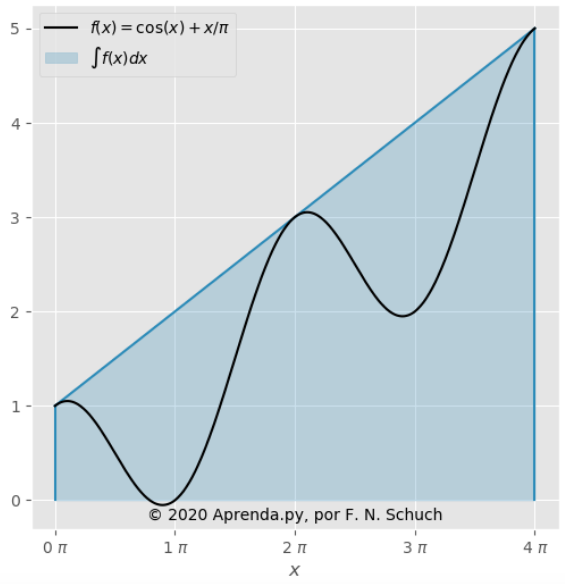

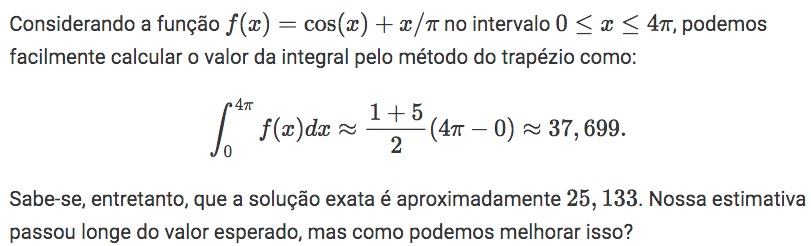

In [2]:
#A área do trapézio da figura acima
import numpy as np

def f(x):
  return np.cos(x) + x/np.pi

def trapezio(x):
  h = x[1] - x[0]
  b = (f(x[0]) + f(x[1]))/2  
  return b*h

x=[0, 4*np.pi]
print(" It = ",trapezio(x))

 It =  37.69911184307752


# Trapézio Composto

Bem, podemos melhorar a aproximação para o cálculo do valor da integral ao aumentarmos o número de trapézios, ou ao usar a regra trapezoidal composta. Ela é dada pela equação:

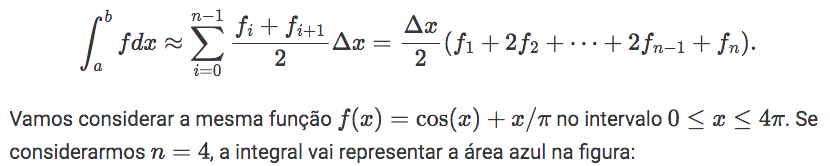

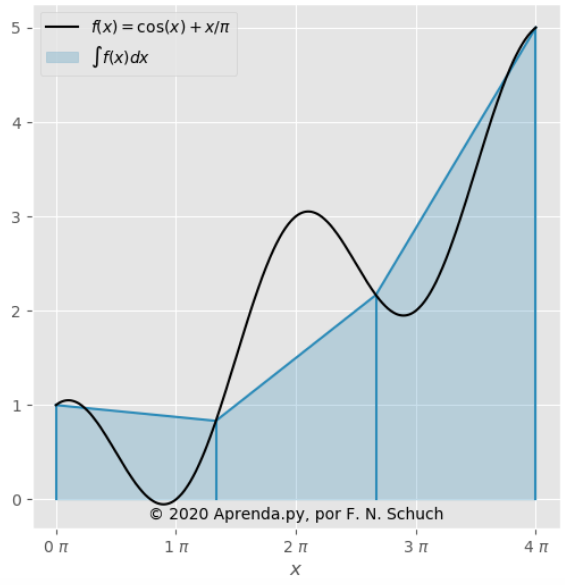



**Melhor agora, não? Calcular seu valor já não é tão trivial, mas que tal começarmos a por a mão na massa?**

**OPÇÃO1:**

In [3]:
##OPÇÃO1:
import numpy as np # Importamos nossa biblioteca preferida

def f(x): # Transcrevemos a função dada
    return np.cos(x) + x/np.pi

dx = 4*np.pi/3 # Calculamos o dx para esse caso

# E finalmente calculamos a integral
# pelo método trapezoidal composto
dx*(f(0*dx) + 2*f(1*dx) + 2*f(2*dx) + f(3*dx))/2

25.132741228718345

A resposta chegou mais perto. Podemos continuar aumentando o número de pontos empregados para diminuir o erro. Mas mais pontos demandariam muito trabalho com a abordagem que usamos aqui, a equação nem caberia na tela. Vamos automatizar esse processo?


**OPÇÃO2:**

In [4]:
##OPÇÃO2: OUTRA FORMA DE SOLUÇÃO NA FORMA DE FUNÇÃO:
import numpy as np

def f(x):
  return np.cos(x) + x/np.pi

def trapezioR(x):
  n = len(x)
  soma = f(x[0]) + f(x[n-1])
  for e in x[1:n-1]:
    soma = soma + 2*f(e) 
  
  h = (x[1]-x[0])/2
  return soma*h

x=[0, np.pi, 2*np.pi, 3*np.pi, 4*np.pi]
print(" It = ",trapezioR(x))  

 It =  25.132741228718345


**OPÇÃO3:**

In [5]:
#OPÇÃO3: OUTRA FORMA DE SOLUÇÃO NA FORMA DE FUNÇÃO:
import numpy as np
#A função a ser integrada:
def f(x):
    return np.cos(x) + x/np.pi
 
#Definir uma função para fazer a integração de f(x) de 0 a 1:
#def trap(f, n, a, b):    #n trapézios
def trap(n, a, b):    #n trapézios
    h = (b - a) / float(n)
    intgr = 0.5 * h * (f(a) + f(b))
    for i in range(1, int(n)):
        intgr = intgr + h * f(a + i * h)
    return intgr
 
a = 0
b = 4*np.pi
n = 10
 
#print(trap(f, n, a, b))]
print(trap(n, a, b))

25.13274122871835


# Implementação

Vamos resolver o método trapezoidal para a mesma função e intervalo, mas agora com ainda mais pontos, que tal n = 21? A representação visual é essa:

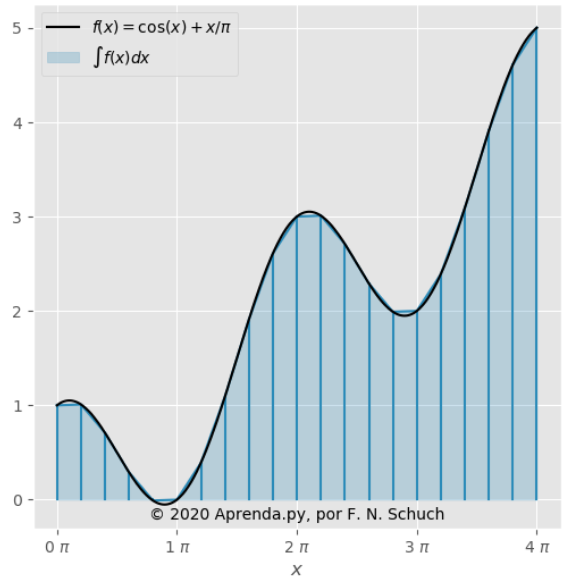


**Vamos ir aumentando o nível de requinte do código, para que ele faça todo o trabalho dessa vez:**

In [6]:
# Aqui definimos o intervalo que queremos, bem como o número de pontos utilizando a função: np.linspace
x = np.linspace(0, 4*np.pi, num=21)  ##para num = 21 pontos

y = f(x) # Nossa função já foi definida no bloco anterior
dx = x[1] - x[0] # Obtém o espaçamento
I = 0. # A operação envolve um somatório, então iniciamos uma variável acumuladora
I += dx*y[0]/2

for i in range(1,x.size-1): # Reflita, por que esse laço vai de 1 até n-1?
    I += dx*y[i]

I += dx*y[-1]/2

print(I) # E finalmente temos o resultado
print(x)

25.132741228718345
[ 0.          0.62831853  1.25663706  1.88495559  2.51327412  3.14159265
  3.76991118  4.39822972  5.02654825  5.65486678  6.28318531  6.91150384
  7.53982237  8.1681409   8.79645943  9.42477796 10.05309649 10.68141502
 11.30973355 11.93805208 12.56637061]


**OBS:**

E estamos cada vez mais perto da resposta exata. Aproveite para experimentar diferentes possibilidades, varie os parâmetros, varie a função, veja o que acontece.

**Uma desvantagem dessa abordagem é que o laço for vai realizar as operações em série, uma de cada vez, e isso é bem ruim do ponto de vista do desempenho computacional.**

*Mais informações sobre **np.linspace**: digite **help(np.linspace)**.*

# **Operador Integral**

$$
dx*(f(0.dx) + 2*f(1.dx) + 2*f(2.dx) + f(3.dx))/2.  
$$
                                  
                                               (exemplo: OPÇÃO1)


Vamos apresentar nossa integral na forma de um operador integral. Retorne até a equação da regra trapezoidal composta e dê uma boa olhada. Percebe o padrão? Todos os termos são multiplicados por **dx**, com exceção do primeiro e do último, que são multiplicados por **dx/2**. Ora, se isso não tem exatamente a aparência de um vetor preenchido pelo valor 1, onde o primeiro e último elemento são divididos por 2, e então todos multiplicados por **dx**, e por fim somados.

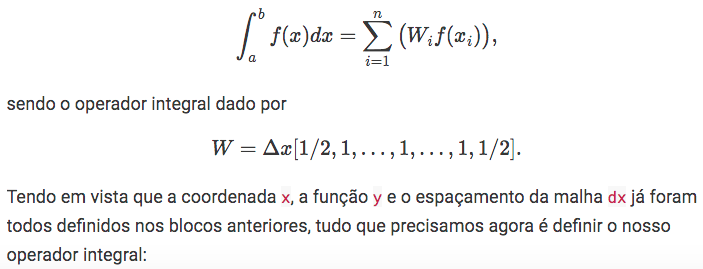

In [7]:
# Iniciamos o operador integral como um vetor
# preenchido por 1, multiplicado por dx
W = dx*np.ones_like(x)

# Dividimos o primeiro e último elemento por 2
for i in [0, -1]:
    W[i] /= 2.0

# A multiplicação do operador pela função e a
# soma dos elementos fornece nossa resposta
np.sum(W * y)

25.132741228718345

Nessa opção, após a inicialização, podemos calcular outras integrais apenas repetindo a última linha do código, aumentando a legibilidade e a chance de reutilização do código, e menos linhas para copiar e colar também são um benefício na hora de procurar e corrigir falhas.

*Todas as operações embutidas nas principais **bibliotecas python (como NumPy e SciPy)** empregam conceitos de otimização e programação vetorial, então são preferíveis por aumentar o desempenho computacional.*

# **Biblioteca SciPy**

Até o momento, vimos quatro maneiras diferentes para calcular uma integral:
$$
\int_{a}^{b} f(x)\, dx 
$$

1.   Com a regra simples, com o **trapézio simples**;
2.   Ao passar para a regra composta as coisas cresceram, com o **trapézio composto**;
1.   Vimos como automatizar o cálculo, e foi então possível experimentar diversas combinações de parâmetros, exemplo: **a função f, n (o número de trapézios), e os limites da integral: a e b**;
2.   Então, aumentamos a elegância e resolvemos o problema de forma matricial, no exemplo foi construído o vetor W = dx*np.ones_like(x).

Agora, a última etapa envolve um dos motivos pelo qual Python tem se tornado tão popular: existe uma infinidade de bibliotecas já programadas, prontas para realizar diversas tarefas. De modo que podemos fazer:

In [9]:
# A função trapz: integra ao longo do eixo determinado usando a regra trapezoidal composta
from scipy.integrate import trapz
trapz(y,x)

25.132741228718345

*Mais simples de solução, não? Repare que obtivemos exatamente a mesma resposta para os três últimos exercícios, mostrando que existem diferentes caminhos a serem trilhados. A prática vai lhe permitir escolher entre eles.*



In [10]:
## Utilizando a integração de propósito geral a função quad(f, a, b)
# Quad() integra f de a a b usando uma técnica da biblioteca FORtran QUADPACK
# Os resultados apresentados são: a solução da integral e o erro (erro numérico no integrando devido ao uso de quad())

import numpy as np
from scipy.integrate import quad

def f(x):
    return np.cos(x) + x/np.pi 

print(quad(f, 0, 4*np.pi))

(25.13274122871834, 7.005585846916572e-09)


# Método dos Trapézios (fórmula geral)

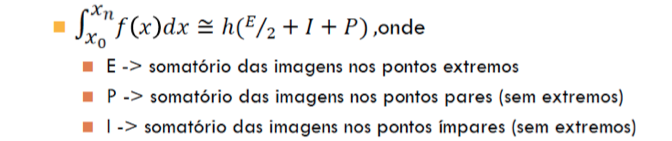



**A fórmula do trapézio simples calcula a integral de uma função f (x) como a área sob a curva que representa f (x), aproximando-a com a soma dos trapézios:**

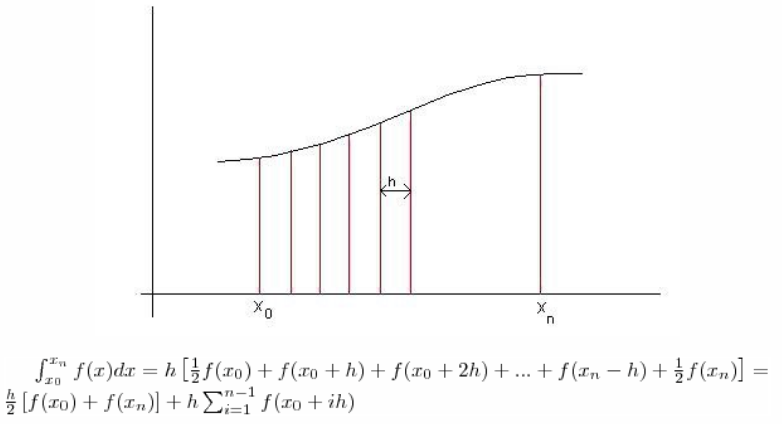

**A área de cada trapézio é calculada como largura vezes a altura média.**

# Exemplo(1): 
Avalie a integral, abaixo, usando a regra básica do trapézio:

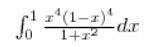

Devemos escrever um pequeno programa para avaliar a integral. Claro que temos que estimar o número de trapézios a usar; a precisão do nosso método depende desse número.



In [15]:
import math
#A função a ser integrada:
def f(x):
    return x**4*(1 - x)**4 / (1 + x **2)

#Definir uma função para fazer a integração de f(x) de 0 a 1:
def trap(f, n):
    h = 1 / float(n)
    intgr = 0.5 * h * (f(0) + f(1))
    for i in range(1, int(n)):
        intgr = intgr + h * f(i * h)
    return intgr
 
print(trap(f, 1000))

0.0012644892673496176


**OBS: Nosso programa básico de integração tem o inconveniente de depender do número de trapézios que temos que trocar manualmente. Como regra básica, se dobrarmos o número de trapézios e obtivermos a mesma resposta dentro de 1 em 1000000, a resposta provavelmente está correta.**

**Atividade 1:**

Execute o programa. Quantos trapézios são necessários para obter um erro relativo de menos de 1 parte em 1.000.000?
Podemos fazer isso da seguinte maneira:

In [16]:
from math import *
n = 1
while abs(trap(f, n) - trap(f, n * 2)) > 1e-6:
    n += 1  
print(n)

6


### No bloco anterior a quantidade de trapézios é igual a 6 para obter um erro < 1e-6. 

In [21]:
# Usando as funções quad() e trapz() e encontrar o erro absoluto entre a integrais
import numpy as np
import scipy
from scipy.integrate import trapz, quad

def f(x):
    return x**4*(1 - x)**4 / (1 + x**2)

x = np.linspace(0, 1, num=6)  #num é o número de divisões ou trapézios para que o erro seja menor que 1e-6
y = f(x) 

integral, error = quad(f, 0, 1)
trap_integral = trapz(y,x)

print("A integral é: %g +/- %.1e" % (integral, error))
print("A aproximação do trapézio com", len(x), "pontos é:", trap_integral)
print("O erro absoluto é:", abs(integral - trap_integral))

A integral é: 0.00126449 +/- 1.1e-14
A aproximação do trapézio com 6 pontos é: 0.0012658861890101191
O erro absoluto é: 1.3969216605006027e-06


# Exemplo(2): 
Calcular


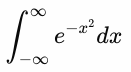


In [23]:
import math
#the function to be integrated:
def f(x):
    return math.exp(-x**2)
 
#define a function to do integration of f(x) btw. a and b:
def trap(f, n, a, b):
    h = (b - a) / float(n)
    intgr = 0.5 * h * (f(a) + f(b))
    for i in range(1, int(n)):
        intgr = intgr + h * f(a + i * h)
    return intgr
 
a = -11
b = 11
n = 100
 
print(trap(f, n, a, b))

1.7724538509055157


In [24]:
#Quantos trapézios são necessários para obter um erro relativo de menos de 1 parte em 1.000.000? 
#Podemos fazer isso da seguinte maneira:
from math import *
n = 1
while abs(trap(f, n, a, b) - trap(f, n * 2, a, b)) > 1e-6:
    n += 1  
print(n)

28


### No bloco anterior a quantidade de trapézios é igual a 25 para obter um erro < 1e-6.

In [26]:
# Usando as funções quad() e trapz() e encontrar o erro absoluto entre a integrais
import numpy as np
import scipy
from scipy.integrate import trapz

def f(x): 
  return np.exp(-x**2)

x = np.linspace(-10, 10, num=25) #num é o número de divisões ou trapézios para que o erro seja menor que 1e-6
y = f(x) 

integral, error = quad(f, -10, 10)
trap_integral = trapz(y,x)

print("A integral é: %g +/- %.1e" % (integral, error))
print("A aproximação do trapézio com", len(x), "pontos é:", trap_integral)
print("O erro absoluto é:", abs(integral - trap_integral))

A integral é: 1.77245 +/- 3.7e-13
A aproximação do trapézio com 5 pontos é: 5.000000000138879
O erro absoluto é: 3.227546149233363


# Exemplo(3): 
Calcular



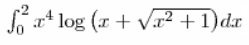





In [ ]:
import math
#the function to be integrated:
def f(x):
    return x ** 4 * log(x + sqrt(x ** 2 + 1))
 
#define a function to do integration of f(x) btw. a and b:
def trap(f, n, a, b):
    h = (b - a) / float(n)
    intgr = 0.5 * h * (f(a) + f(b))
    for i in range(1, int(n)):
        intgr = intgr + h * f(a + i * h)
    return intgr
 
a = 0
b = 2
n = 1000
 
print(trap(f, n, a, b))

8.15338190372611


In [ ]:
#Quantos trapézios são necessários para obter um erro relativo de menos de 1 parte em 1.000.000? 
#Podemos fazer isso da seguinte maneira:
from math import *
n = 1
while abs(trap(f, n, a, b) - trap(f, n * 2, a, b)) > 1e-6:
    n += 1  
print(n)

3653


### No bloco anterior a quantidade de trapézios é igual a 3635 para obter um erro < 1e-6. 

In [ ]:
# Usando as funções quad() e trapz() e encontrar o erro absoluto entre a integrais
import numpy as np
import scipy
from scipy.integrate import quad, trapz

def f(x):
  return x** 4 * np.log(x + np.sqrt(x** 2 + 1))

x = np.linspace(0, 2, num=3653)   #num é o número de divisões ou trapézios para que o erro seja menor que 1e-6
y = f(x) 

integral, error = quad(f, 0, 2)

trap_integral = trapz(y,x)

print("A integral é: %g +/- %.1e" % (integral, error))
print("A aproximação do trapézio com", len(x), "pontos é:", trap_integral)
print("O erro absoluto é:", abs(integral - trap_integral))

A integral é: 8.15336 +/- 9.1e-14
A aproximação do trapézio com 3653 pontos é: 8.153365453227877
O erro absoluto é: 1.3334167103806749e-06


# **EXERCÍCIOS**

# EXERCÍCIO(1)

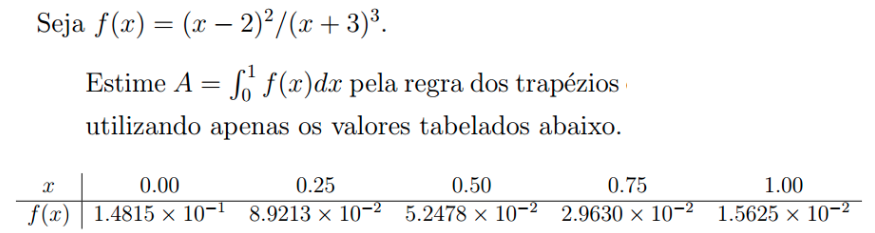

# EXERCÍCIO(2)

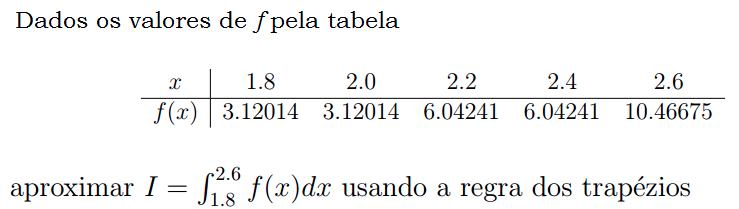